In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
import time

In [2]:
target_resolution = 1080 #Height in pixels (in range (0,2100))
img_original = cv2.imread("media//peas_2.bmp")
img_crop = img_original.copy()[:-63,14:] # To preserve aspect ratio (16/9)
cv2.namedWindow('Image',cv2.WINDOW_NORMAL)
cv2.setWindowProperty('Image', cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
scale = target_resolution/img_crop.shape[0]
img = cv2.resize(img_crop, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
cv2.imshow("Image",img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [3]:
y = len(img)
x = len(img[0])
img_bnw = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_median  = cv2.medianBlur(img_bnw,5)

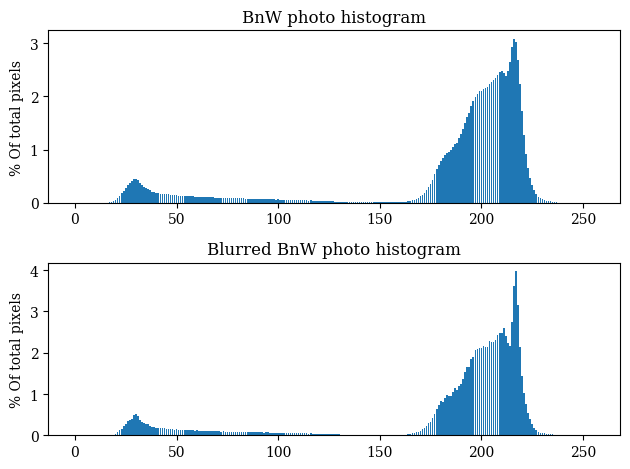

In [13]:
histogram_noblur = np.zeros(256)
histogram_blur = np.zeros(256)
for i in range(y):
    for j in range(x):
        histogram_noblur[img_bnw[i][j]]+=1
        histogram_blur[img_median[i][j]]+=1

histogram_noblur /= 0.01*x*y
histogram_blur /= 0.01*x*y

fig, [ax1,ax2] = plt.subplots(2,1)
ax1.bar(np.arange(256),histogram_noblur)
ax2.bar(np.arange(256),histogram_blur)
ax1.set_title("BnW photo histogram")
ax2.set_title("Blurred BnW photo histogram")
ax1.set_ylabel("% Of total pixels")
ax2.set_ylabel("% Of total pixels")
plt.tight_layout()
plt.show()

In [4]:
_,img_bin = cv2.threshold(img_median,150,255,cv2.THRESH_BINARY_INV)

cv2.imshow("Image",img_bnw)
cv2.waitKey(0)
cv2.imshow("Image",img_median)
cv2.waitKey(0)
cv2.imshow("Image",img_bin)
cv2.waitKey(0)
cv2.destroyAllWindows()

Helper functions for labelling algorithm

In [7]:
def checkNeighbors(i,j,MATRIX):
    exclude = np.zeros(8).astype(bool)
    output = np.zeros(8)
    # Deal with edge cases
    if i==0:
        exclude[1:4] = 1
    elif i==len(MATRIX)-1:
        exclude[5:9] = 1
    if j==0:
        exclude[3:6] = 1
    elif j == len(MATRIX[0])-1:
        exclude[:2] = 1
        exclude[-1] = 1
        
    # Return valid neighbor values
    for index,shouldExclude in enumerate(exclude):
        if shouldExclude:
            output[index] = 0
        else:
            di,dj = numToIndexOffset(index)
            output[index] = MATRIX[i+di][j+dj]
    return output

def numToIndexOffset(i):
    # zero-indexed
    if not i in range(8):
        print("index out of range for 8-connected regions")
        return
    if i == 0:
        return  0, 1
    elif i == 1:
        return -1, 1
    elif i == 2:
        return -1, 0
    elif i == 3:
        return -1,-1
    elif i == 4:
        return  0,-1
    elif i == 5:
        return  1,-1
    elif i == 6:
        return  1, 0
    elif i == 7:
        return  1, 1


Proposed labelling algorithm: $\mathcal{O}(n^2)$

In [8]:
def classify_old(binary_image):
    A_old = np.multiply(1/255,binary_image)
    P_old = np.zeros(A_old.shape)
    N_old = 0
    ydim,xdim = A_old.shape
    found = True
    while found:
        found = False
        for i in range(ydim):
            for j in range(xdim):
                if (A_old[i][j]==1 and P_old[i][j]==0 and not found):
                    N_old+=1
                    P_old[i][j]=N_old
                    found = True
                    # Propagate
                    shouldContinue = True
                    while shouldContinue:
                        shouldContinue = False
                        for k in range(ydim):
                            for l in range(xdim):
                                if (A_old[k][l]==1 and P_old[k][l]==0):
                                    for neighbor in checkNeighbors(k,l,P_old):
                                        if neighbor == N_old:
                                            P_old[k][l] = N_old
                                            shouldContinue = True
                                        if shouldContinue: break
                                if shouldContinue: break
                            if shouldContinue: break
    return N_old,P_old

In [ ]:
""" cv2.imwrite("peas_classified.bmp",P_old)
plt.figure()
plt.axis("off")
plt.imshow(P_old,cmap="gray",vmin=0,vmax=N_old) """
#plt.savefig("peas_classified.png",dpi=350,bbox_inches='tight', pad_inches=0)

' cv2.imwrite("peas_classified.bmp",P_old)\nplt.figure()\nplt.axis("off")\nplt.imshow(P_old,cmap="gray",vmin=0,vmax=N_old) '

This code has quadratic complexity, so if we go from 180p to full HD, we need 1296x more computation. For ~1minute execution @ 180p, this means execution at full HD will take upwards of 30 hours. Optimization is clearly needed

Our proposed labelling algorithm: $\mathcal{O}(n)$

In [10]:
def classify(binary_image):
    A = np.multiply(1/255,binary_image)
    P = np.ones(A.shape)*(-1)
    N = 0
    ydim,xdim = A.shape

    def propagate(i_0,j_0,A,P,N):
        Stack=[(i_0,j_0)]
        while Stack:
            i,j = Stack.pop()
            for neighborNumber,value in enumerate(checkNeighbors(i,j,A)):
                di,dj = numToIndexOffset(neighborNumber)
                if (value==1 and P[i+di][j+dj]==-1):
                    #We assume good preprocessing -> no overlap between objects
                    P[i+di][j+dj] = N
                    Stack.append((i+di, j+dj))
        return

    for i in range(ydim):
        for j in range(xdim):
            if P[i][j] != -1: #Pixel is already found
                continue
            P[i][j]=A[i][j]
            if A[i][j] == 1: #New object is found
                N+=1
                propagate(i,j,A,P,N) # Modifies P
            
    return N,P

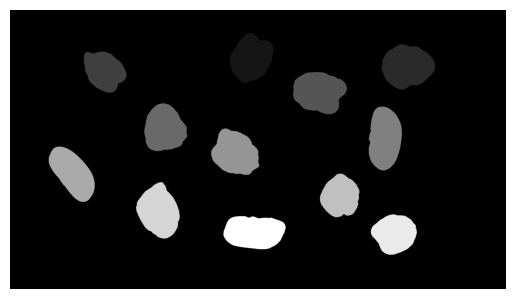

In [11]:
N,P = classify(img_bin)
plt.figure()
plt.axis("off")
plt.imshow(P,cmap="gray",vmin=0,vmax=N)
plt.savefig("peas_1080.png",dpi=400)

$\text{RUNTIME ANALYSIS}$

In [12]:
""" cv2.namedWindow("Image",cv2.WINDOW_NORMAL)
cv2.setWindowProperty('Image', cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN) 
cv2.destroyAllWindows()"""

times=[]
resolutions = np.linspace(180,1440,40)#[180,360,480,720,1080]#200,220,240,260,280,300]
for res in resolutions:
    scale = res/img_crop.shape[0]
    img_test = cv2.resize(img_crop, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    xdim,ydim = img_test.shape[0:2]
    img_bnw_test = cv2.cvtColor(img_test,cv2.COLOR_BGR2GRAY)
    kernel_size = max(3,round(5*res/1080))
    if kernel_size%2==0:
        kernel_size+=1
    img_median_test  = cv2.medianBlur(img_bnw_test,kernel_size)
    _,img_bin_test = cv2.threshold(img_median_test,150,255,cv2.THRESH_BINARY_INV)
    t0 = time.perf_counter_ns()
    _,img_labelled = classify(img_bin_test)
    t1 = time.perf_counter_ns()
    times.append(round((t1-t0)*1e-9,2))

KeyboardInterrupt: 

In [27]:
times_old_2=[]
for res in np.linspace(1,180,20):
    scale = res/img_crop.shape[0]
    img_test = cv2.resize(img_crop, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    xdim,ydim = img_test.shape[0:2]
    img_bnw_test = cv2.cvtColor(img_test,cv2.COLOR_BGR2GRAY)
    kernel_size = max(3,round(5*res/1080))
    if kernel_size%2==0:
        kernel_size+=1
    img_median_test  = cv2.medianBlur(img_bnw_test,kernel_size)
    _,img_bin_test = cv2.threshold(img_median_test,150,255,cv2.THRESH_BINARY_INV)
    t0 = time.perf_counter_ns()
    _,img_labelled_old = classify_old(img_bin_test)
    t1 = time.perf_counter_ns()
    times_old_2.append(round((t1-t0)*1e-9,2))
    print(round((t1-t0)*1e-9,2))

0.0
0.0
0.01
0.03
0.07
0.19
0.36
0.62
1.03
1.61
2.54
3.91
5.12
7.24
9.31
12.15
16.11
20.22
25.69
31.97


In [28]:
times_old_2 = [0,0,0.1,0.3,0.7,0.19,0.36,0.62,1.03,1.61,2.54,3.91,5.12,7.24,9.31,12.15,16.11,20.22,25.69,31.97] #Calculated runtimes for res_old_2
res_old_2 = np.linspace(1,180,20)
times_old = [75.99, 155.68, 285.71, 754.26, 1302.7, 1966.23] #Calculated runtimes for res_old
res_old = np.linspace(180,360,6)

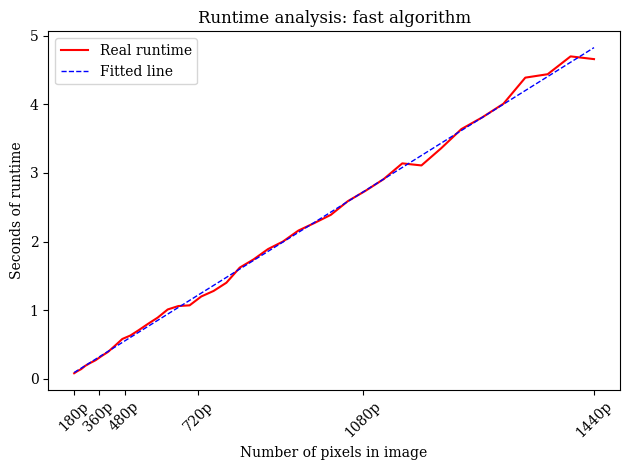

In [103]:
heights = [180, 360, 480, 720, 1080, 1440]
tick_positions = [h * h * 16/9 for h in heights]

coeffs_lin = np.polyfit(resolutions**2*16/9,times,1)
p_lin = np.poly1d(coeffs_lin)
r_fit = np.linspace(180,1440,1000)
t_fit = p_lin(r_fit**2*16/9)

plt.figure()
plt.plot(resolutions**2*16/9,times,"r",label="Real runtime")
plt.plot(r_fit**2*16/9,t_fit,"--b",label="Fitted line",linewidth=1)
plt.xlabel("Number of pixels in image")
plt.ylabel("Seconds of runtime")
plt.title("Runtime analysis: fast algorithm")
plt.xticks(tick_positions,[f"{h}p" for h in heights],rotation=45)
plt.tight_layout()
plt.legend()
plt.show()
#plt.savefig("Runtime_O(n).png",dpi=400)

26
26


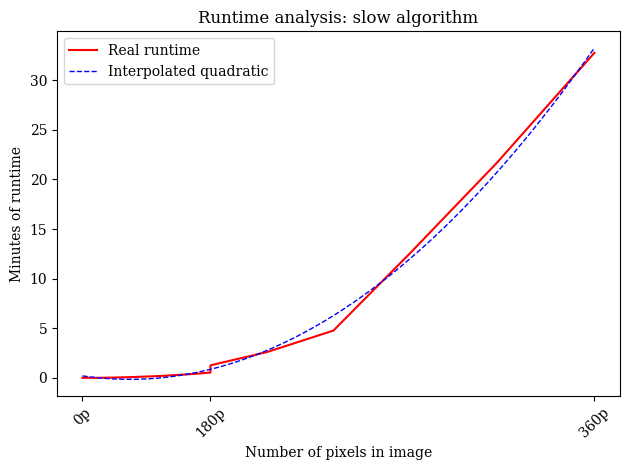

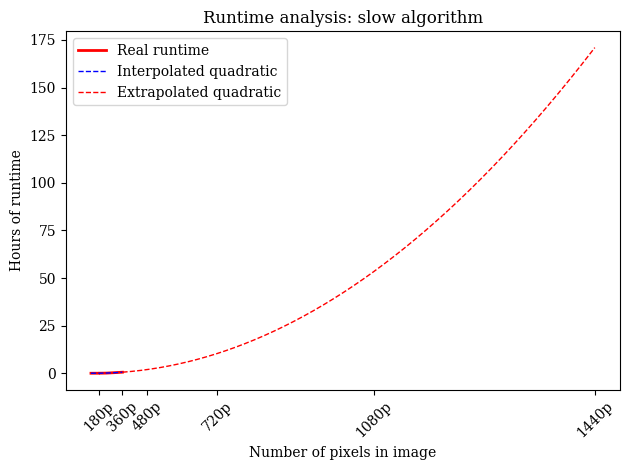

In [102]:
r = np.concatenate((res_old_2,res_old))
t = times_old_2 + times_old
print(len(r))
print(len(t))

coeffs = np.polyfit(r**2*16/9,t,2)
p = np.poly1d(coeffs)
r_fit_in = np.linspace(0,360,1000)
r_fit_ex = np.linspace(360,1440,1000)
t_fit_in = p(r_fit**2*16/9)
t_fit_ex = p(r_fit_ex**2*16/9)

plt.figure()
plt.plot(r**2*16/9,[j/60 for j in t],"-r",label="Real runtime")
plt.plot(r_fit_in**2*16/9,t_fit_in/60,"--b",label="Interpolated quadratic",linewidth = 1)
plt.ylabel("Minutes of runtime")
plt.xlabel("Number of pixels in image")
plt.title("Runtime analysis: slow algorithm")
plt.xticks([0,180**2*16/9,360**2*16/9],[f"{h}p" for h in [0,180,360]],rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
#plt.savefig("Runtime_O(n2).png",dpi=400)

plt.figure()
plt.plot(r**2*16/9,[j/3600 for j in t],"-r",label="Real runtime",linewidth = 2)
plt.plot(r_fit**2*16/9,t_fit/3600,"--b",label="Interpolated quadratic",linewidth = 1)
plt.plot(r_fit_ex**2*16/9,t_fit_ex/3600,"--r",label="Extrapolated quadratic",linewidth = 1)
plt.ylabel("Hours of runtime")
plt.xlabel("Number of pixels in image")
plt.title("Runtime analysis: slow algorithm")
plt.xticks(tick_positions,[f"{h}p" for h in heights],rotation=45)
plt.tight_layout()
plt.legend()
plt.show()
#plt.savefig("Runtime_extrapolated_O(n2).png",dpi = 400)

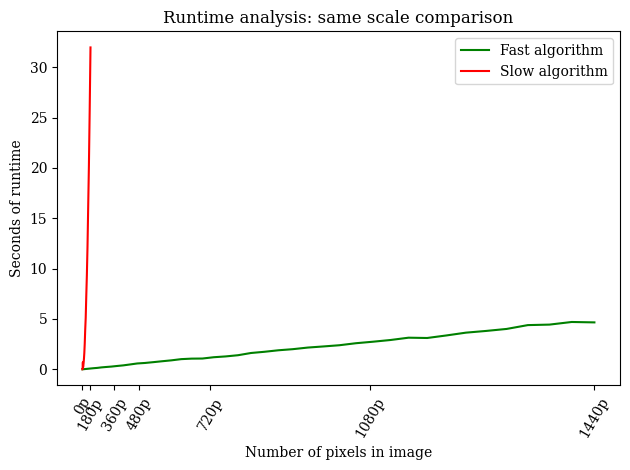

In [123]:
plt.figure()
plt.plot(np.concatenate(([0],resolutions))**2*16/9,[0]+times,"g",label="Fast algorithm")
plt.plot(r[:20]**2*16/9,[j for j in t[:20]],"r",label="Slow algorithm")
plt.xlabel("Number of pixels in image")
plt.ylabel("Seconds of runtime")
plt.title("Runtime analysis: same scale comparison")
plt.xticks([0]+tick_positions,["0p"]+[f"{h}p" for h in heights],rotation=60)
plt.tight_layout()
plt.legend()
plt.show()
#plt.savefig("Runtime_comparison.png",dpi=400)

If we are to trust the extrapolation up to 1440p, we can expect a time decrease of over 10000000% when switching algorithms!